# ASDMotion V1 — 1D-CNN SMM Detector (TensorFlow / Keras)\n\nTrains the SMM detector in three stages — **Initial → Improved → Tuned** — and saves the final model as `v1_model.keras`. Run after the prep notebook.

## 1. Import Libraries

In [1]:
# ── Imports & GPU setup ─────────────────────────────────────────────
import os, json, csv
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np, tensorflow as tf

# GPU config: must run before TF initializes the GPU
gpus = tf.config.list_physical_devices("GPU")
for g in gpus:
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except Exception:
        pass

from tensorflow.keras import layers, models, callbacks, optimizers, losses, metrics
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import keras_tuner as kt

tf.random.set_seed(0); np.random.seed(0)

print("TensorFlow", tf.__version__, "| keras-tuner", kt.__version__,
      "| running on:", [g.name for g in gpus] if gpus else "CPU")
print(tf.config.list_physical_devices("GPU"))

TensorFlow 2.20.0 | keras-tuner 1.4.8 | running on: ['/physical_device:GPU:0']
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Load Data & Subject-Grouped Split

In [2]:
# ── Config ──────────────────────────────────────────────────────────
OUT_DIR       = "prepared"      # arrays produced by the prep notebook
EPOCHS        = 50
BATCH         = 256
LR            = 1e-3
WEIGHT_DECAY  = 1e-3
VAL_FRAC      = 0.15
SEED          = 0
LABEL_SMOOTH  = 0.05
TARGET_RECALL = 0.91
KERNEL        = 9
PATIENCE      = 20
NOISE, SCALE, KP_DROP_P, SHIFT = 0.05, 0.10, 0.12, 4   # augmentation (train only)

In [3]:
# ── Load prepared arrays (channels-last for Keras Conv1D) ───────────
def load(split):
    X = np.load(f"{OUT_DIR}/X_{split}.npy").transpose(0, 2, 1).astype("float32")  # (N,20,90)->(N,90,20)
    y = np.load(f"{OUT_DIR}/y_{split}.npy").astype("float32")
    cat = np.load(f"{OUT_DIR}/cat_{split}.npy").astype(int)
    subj = np.array([r["subject"] for r in csv.DictReader(open(f"{OUT_DIR}/meta_{split}.csv"))])
    return X, y, cat, subj

Xtr_all, ytr_all, cat_tr, subj_tr = load("train")
Xte, yte, cat_te, subj_te = load("test")
N, L, C = Xtr_all.shape
print("train", Xtr_all.shape, "| test", Xte.shape)

train (208130, 90, 20) | test (11932, 90, 20)


In [4]:
# ── Subject-grouped validation split (no subject in both train & val) ─
rng = np.random.default_rng(SEED)
uq = np.unique(subj_tr); rng.shuffle(uq)
nv = max(1, int(len(uq) * VAL_FRAC)); val_subj = set(uq[:nv])
is_val = np.array([s in val_subj for s in subj_tr])
Xtr, ytr = Xtr_all[~is_val], ytr_all[~is_val]
Xval, yval = Xtr_all[is_val], ytr_all[is_val]
print(f"train windows {len(Xtr)} | val windows {len(Xval)} | val subjects {nv}/{len(uq)}")

train windows 170296 | val windows 37834 | val subjects 43/289


## 3. Augmentation Layer & Evaluation Helpers

In [5]:
# ── Train-only augmentation layer (identity at inference) ───────────
@tf.keras.utils.register_keras_serializable()
class Augment(layers.Layer):
    def __init__(self, noise=NOISE, scale=SCALE, kp_drop_p=KP_DROP_P, shift=SHIFT, n_sp=10, **kw):
        super().__init__(**kw)
        self.noise, self.scale, self.kp_drop_p, self.shift, self.n_sp = noise, scale, kp_drop_p, shift, n_sp
    def build(self, input_shape):
        # keep mask broadcasts over both halves only if C == 2 * n_sp
        assert input_shape[-1] == 2 * self.n_sp, \
            f"Augment expects {2*self.n_sp} channels, got {input_shape[-1]}"
        super().build(input_shape)
    def call(self, x, training=None):
        if not training:
            return x
        b = tf.shape(x)[0]
        sp, cf = x[..., :self.n_sp], x[..., self.n_sp:]
        sp = sp + tf.random.normal(tf.shape(sp), 0.0, self.noise)
        sp = sp * tf.random.uniform([b, 1, 1], 1 - self.scale, 1 + self.scale)
        keep = tf.cast(tf.random.uniform([b, 1, self.n_sp]) > self.kp_drop_p, x.dtype)
        x = tf.concat([sp * keep, cf * keep], axis=-1)
        return tf.roll(x, tf.random.uniform([], -self.shift, self.shift + 1, dtype=tf.int32), axis=1)
    def get_config(self):
        c = super().get_config()
        c.update(noise=self.noise, scale=self.scale, kp_drop_p=self.kp_drop_p,
                 shift=self.shift, n_sp=self.n_sp); return c

In [6]:
# ── Evaluation helpers (shared by all three models) ─────────────────
def pick_threshold(y, s, target=TARGET_RECALL):
    cand = [(t, precision_score(y, s >= t, zero_division=0))
            for t in np.unique(np.round(s, 3))
            if recall_score(y, s >= t, zero_division=0) >= target]
    if cand: return max(cand, key=lambda c: c[1])[0]  # highest precision meeting recall target
    ts = np.linspace(0.02, 0.95, 40)
    return max(ts, key=lambda t: f1_score(y, s >= t, zero_division=0))

def evaluate(model, name):
    thr = pick_threshold(yval, model.predict(Xval, batch_size=BATCH, verbose=0).ravel())
    s = model.predict(Xte, batch_size=BATCH, verbose=0).ravel(); pred = s >= thr
    rec = lambda m: float(pred[m].mean()) if m.any() else float("nan")
    res = dict(model=name,
        PR_AUC=round(average_precision_score(yte, s), 3),
        F1=round(f1_score(yte, pred, zero_division=0), 3),
        precision=round(precision_score(yte, pred, zero_division=0), 3),
        recall=round(recall_score(yte, pred, zero_division=0), 3),
        recall_gross=round(rec(cat_te == 1), 3), recall_fine=round(rec(cat_te == 2), 3),
        specificity=round(float((~pred[cat_te == 0]).mean()) if (cat_te == 0).any() else float("nan"), 3),
        threshold=round(float(thr), 3))
    print(name, "->", res); return res, thr

def plot_curves(history, title):
    h = history.history
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(h["loss"], label="train"); ax[0].plot(h["val_loss"], label="val")
    ax[0].set_title(f"{title} — loss"); ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(h["pr_auc"], label="train"); ax[1].plot(h["val_pr_auc"], label="val")
    ax[1].set_title(f"{title} — PR-AUC"); ax[1].set_xlabel("epoch"); ax[1].legend(); ax[1].grid(alpha=.3)
    fig.tight_layout(); plt.show()

METRICS = ["accuracy", metrics.AUC(curve="PR", name="pr_auc")]
es = lambda p=PATIENCE: callbacks.EarlyStopping(monitor="val_pr_auc", mode="max",
                                                patience=p, restore_best_weights=True)
rlrop = lambda: callbacks.ReduceLROnPlateau(monitor="val_pr_auc", mode="max",
                                            factor=0.5, patience=5, min_lr=1e-5)

I0000 00:00:1784393999.925891    2614 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4095 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


## 4. Model Training

### 4.1 Initial Model\nA minimal baseline — two plain conv layers, no batch-norm, no augmentation — to establish a floor.

In [7]:
# ── 4.1 Initial model: a minimal baseline (2 conv layers, no BN / aug) ─
def build_initial(L, C):
    inp = layers.Input(shape=(L, C))
    x = layers.Conv1D(32, KERNEL, padding="same", activation="relu")(inp)
    x = layers.Conv1D(64, KERNEL, padding="same", activation="relu")(x)
    x = layers.Conv1D(128, KERNEL, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation="relu")(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    return models.Model(inp, out, name="initial")

model_init = build_initial(L, C)
model_init.compile(optimizer="adam", loss="binary_crossentropy", metrics=METRICS)
model_init.summary()

Model: "initial"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 90, 20)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 90, 32)         │         5,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 90, 64)         │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 90, 128)        │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,465 (415.88 KB)

 Trainable params: 106,465 (415.88 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history_init = model_init.fit(Xtr, ytr, validation_data=(Xval, yval),
                              epochs=EPOCHS, batch_size=BATCH,
                              callbacks=[es(), rlrop()], verbose=1)

Epoch 1/50
 35/666 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6922 - loss: 0.5919 - pr_auc: 0.3617

I0000 00:00:1784394006.435572    6295 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


666/666 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.8005 - loss: 0.4512 - pr_auc: 0.6650 - val_accuracy: 0.8446 - val_loss: 0.3892 - val_pr_auc: 0.7785 - learning_rate: 0.0010
Epoch 2/50
666/666 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8556 - loss: 0.3483 - pr_auc: 0.8076 - val_accuracy: 0.8520 - val_loss: 0.3757 - val_pr_auc: 0.7992 - learning_rate: 0.0010
Epoch 3/50
666/666 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8688 - loss: 0.3201 - pr_auc: 0.8367 - val_accuracy: 0.8621 - val_loss: 0.3637 - val_pr_auc: 0.8136 - learning_rate: 0.0010
Epoch 4/50
666/666 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8782 - loss: 0.2999 - pr_auc: 0.8560 - val_accuracy: 0.8621 - val_loss: 0.3641 - val_pr_auc: 0.8182 - learning_rate: 0.0010
Epoch 5/50
666/666 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8860 - loss: 0.2828 - pr_auc: 0.8712 - val_accuracy: 0.8645 - val_loss: 0.3622 - val_pr_auc: 0.8209 - learning_rate: 0.0010
Epoch 6/50
666/666 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accur

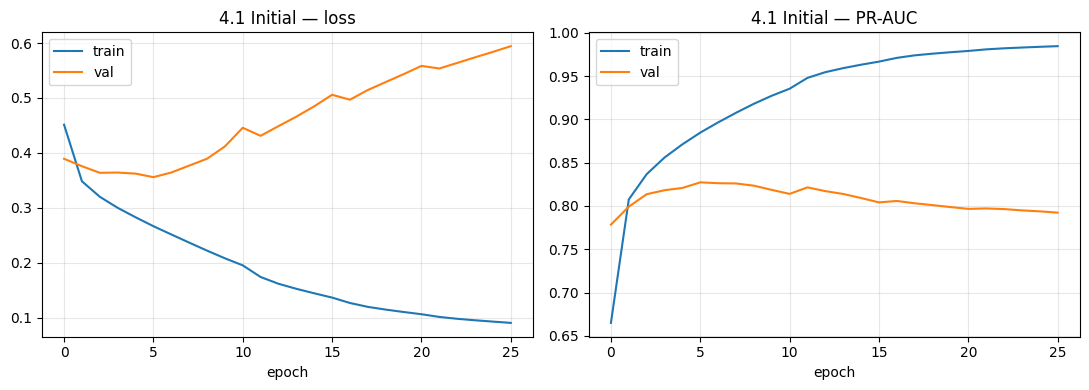

initial -> {'model': 'initial', 'PR_AUC': 0.811, 'F1': 0.548, 'precision': 0.393, 'recall': 0.904, 'recall_gross': 0.911, 'recall_fine': 0.898, 'specificity': 0.474, 'threshold': 0.056}


In [9]:
plot_curves(history_init, "4.1 Initial")
res_init, thr_init = evaluate(model_init, "initial")

### 4.2 Improved Model\nThe full V1: in-graph augmentation, Conv 32/64/128 with batch-norm and dropout, AdamW, and label smoothing.

In [ ]:
# ── 4.2 Improved model: full V1 (augment + Conv32/64/128 + BN + dropout) ─
def build_improved(L, C, k=KERNEL):
    inp = layers.Input(shape=(L, C))
    x = Augment()(inp)
    x = layers.Conv1D(32, k, padding="same")(x); x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Conv1D(64, k, padding="same")(x); x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.Conv1D(128, k, padding="same")(x); x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64)(x); x = layers.ReLU()(x); x = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    return models.Model(inp, out, name="improved")

model = build_improved(L, C)
model.compile(optimizer=optimizers.AdamW(LR, weight_decay=WEIGHT_DECAY),
              loss=losses.BinaryCrossentropy(label_smoothing=LABEL_SMOOTH), metrics=METRICS)
model.summary()

Model: "improved"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 90, 20)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augment (Augment)               │ (None, 90, 20)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 90, 32)         │         5,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 90, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 90, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 90, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 90, 64)         │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 90, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 90, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 90, 128)        │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 90, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 90, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,361 (419.38 KB)

 Trainable params: 106,913 (417.63 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/50
666/666 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.7618 - loss: 0.5365 - pr_auc: 0.5913 - val_accuracy: 0.8237 - val_loss: 0.4838 - val_pr_auc: 0.7374 - learning_rate: 0.0010
Epoch 2/50
666/666 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8202 - loss: 0.4522 - pr_auc: 0.7194 - val_accuracy: 0.8469 - val_loss: 0.4377 - val_pr_auc: 0.7835 - learning_rate: 0.0010
Epoch 3/50
666/666 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8355 - loss: 0.4282 - pr_auc: 0.7591 - val_accuracy: 0.8537 - val_loss: 0.4357 - val_pr_auc: 0.7992 - learning_rate: 0.0010
Epoch 4/50
666/666 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8430 - loss: 0.4175 - pr_auc: 0.7758 - val_accuracy: 0.8564 - val_loss: 0.4245 - val_pr_auc: 0.7994 - learning_rate: 0.0010
Epoch 5/50
666/666 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8474 - loss: 0.4103 - pr_auc: 0.7860 - val_accuracy: 0.8511 - val_loss: 0.4144 - val_pr_auc: 0.8084 - learning_rate: 0.0010
Epoch 6/50
666/666 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/s

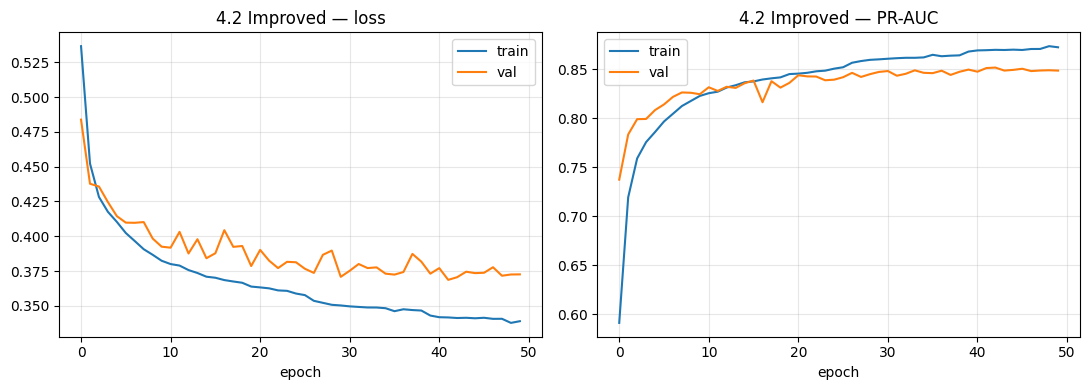

improved -> {'model': 'improved', 'PR_AUC': 0.843, 'F1': 0.585, 'precision': 0.429, 'recall': 0.916, 'recall_gross': 0.93, 'recall_fine': 0.907, 'specificity': 0.54, 'threshold': 0.091}


In [11]:
history_impr = model.fit(Xtr, ytr, validation_data=(Xval, yval),
                         epochs=EPOCHS, batch_size=BATCH,
                         callbacks=[es(), rlrop()], verbose=1)

plot_curves(history_impr, "4.2 Improved")
res_impr, thr_impr = evaluate(model, "improved")

### 4.3 Model Tuning
A `keras-tuner` Bayesian-optimization search around the improved model. Filter widths stay fixed (32/64/128); the search covers kernel size (multiples of 3), head dropout, learning rate, weight decay, and augmentation noise strength. Early stopping and LR reduction both monitor `val_pr_auc`, matching the tuning objective.

In [ ]:
# ── 4.3 Model tuning: keras-tuner Bayesian search around the improved model ─
FILTERS = 32  # fixed — not a tuned hyperparameter

def build_tuned(hp):
    k        = hp.Choice("kernel", [3, 9, 15])           # multiples of 3, odd -> symmetric padding
    head_dro = hp.Choice("head_dropout", [0.3, 0.4, 0.5])
    lr       = hp.Choice("lr", [1e-3, 5e-4])
    wd       = hp.Choice("weight_decay", [1e-4, 1e-3, 3e-3])
    noise    = hp.Choice("aug_noise", [0.05, 0.10])
    CONV_DRO = 0.2                                        # fixed to keep the space small

    inp = layers.Input(shape=(L, C))
    x = Augment(noise=noise)(inp)

    x = layers.Conv1D(FILTERS, k, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.SpatialDropout1D(CONV_DRO)(x)

    x = layers.Conv1D(FILTERS*2, k, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.SpatialDropout1D(CONV_DRO)(x)

    x = layers.Conv1D(FILTERS*4, k, padding="same")(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64)(x); x = layers.ReLU()(x)
    x = layers.Dropout(head_dro)(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    m = models.Model(inp, out, name="tuned")
    m.compile(
        optimizer=optimizers.AdamW(learning_rate=lr, weight_decay=wd),
        loss=losses.BinaryCrossentropy(label_smoothing=LABEL_SMOOTH),
        metrics=METRICS,
    )
    return m

tuner = kt.BayesianOptimization(build_tuned,
                                objective=kt.Objective("val_pr_auc", "max"),
                                max_trials=15, overwrite=True,
                                directory="kt_dir", project_name="asd_v1")
tuner.search(Xtr, ytr, validation_data=(Xval, yval),
             epochs=50, batch_size=BATCH, callbacks=[es(8), rlrop()], verbose=1)
best_hp = tuner.get_best_hyperparameters(1)[0]
print("best hyperparameters:", best_hp.values)

Trial 15 Complete [00h 02m 28s]
val_pr_auc: 0.8264842629432678

Best val_pr_auc So Far: 0.8453521132469177
Total elapsed time: 00h 45m 45s
best hyperparameters: {'kernel': 15, 'head_dropout': 0.3, 'lr': 0.001, 'weight_decay': 0.0001, 'aug_noise': 0.05}


In [13]:
# retrain the best configuration for the full schedule
model_tuned = build_tuned(best_hp)
history_tuned = model_tuned.fit(Xtr, ytr, validation_data=(Xval, yval),
                                epochs=EPOCHS, batch_size=BATCH,
                                callbacks=[es(), rlrop()], verbose=1)

Epoch 1/50
666/666 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - accuracy: 0.7491 - loss: 0.5548 - pr_auc: 0.5719 - val_accuracy: 0.7571 - val_loss: 0.5391 - val_pr_auc: 0.6168 - learning_rate: 0.0010
Epoch 2/50
666/666 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8004 - loss: 0.4844 - pr_auc: 0.6598 - val_accuracy: 0.8491 - val_loss: 0.4226 - val_pr_auc: 0.7839 - learning_rate: 0.0010
Epoch 3/50
666/666 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8238 - loss: 0.4481 - pr_auc: 0.7268 - val_accuracy: 0.8508 - val_loss: 0.4223 - val_pr_auc: 0.7850 - learning_rate: 0.0010
Epoch 4/50
666/666 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8309 - loss: 0.4358 - pr_auc: 0.7466 - val_accuracy: 0.8498 - val_loss: 0.4145 - val_pr_auc: 0.7977 - learning_rate: 0.0010
Epoch 5/50
666/666 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8356 - loss: 0.4270 - pr_auc: 0.7596 - val_accuracy: 0.8556 - val_loss: 0.4106 - val_pr_auc: 0.8012 - learning_rate: 0.0010
Epoch 6/50
666/666 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/s

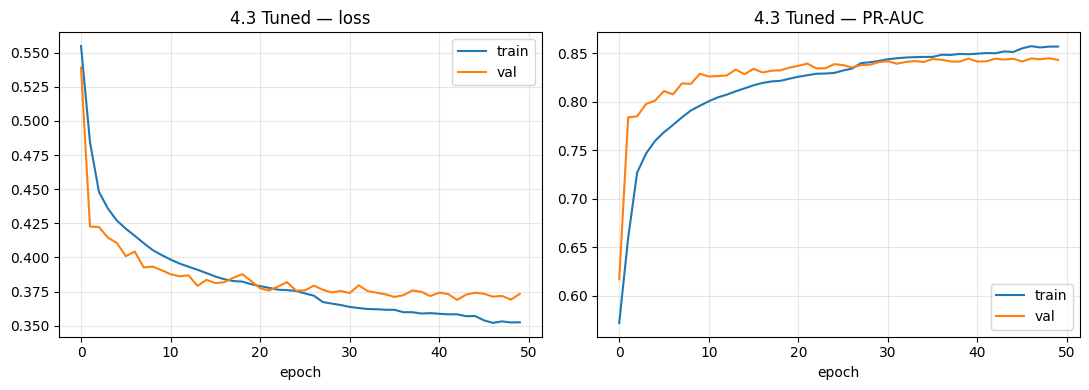

tuned -> {'model': 'tuned', 'PR_AUC': 0.832, 'F1': 0.557, 'precision': 0.399, 'recall': 0.92, 'recall_gross': 0.924, 'recall_fine': 0.917, 'specificity': 0.478, 'threshold': 0.093}


In [14]:
plot_curves(history_tuned, "4.3 Tuned")
res_tuned, thr_tuned = evaluate(model_tuned, "tuned")

## 5. Final Evaluation & Save\nCompare the three models and save the best of improved/tuned as the final V1.

In [15]:
# ── Compare the three, pick the final V1 (best val PR-AUC of improved/tuned) ─
print(f"{'model':10s}{'PR_AUC':>9}{'F1':>8}{'precision':>11}{'recall':>9}{'rec_fine':>10}{'spec':>7}")
for r in (res_init, res_impr, res_tuned):
    print(f"{r['model']:10s}{r['PR_AUC']:>9}{r['F1']:>8}{r['precision']:>11}{r['recall']:>9}"
          f"{r['recall_fine']:>10}{r['specificity']:>7}")

val_ap = {"improved": max(history_impr.history["val_pr_auc"]),
          "tuned":    max(history_tuned.history["val_pr_auc"])}
final = max(val_ap, key=val_ap.get)
final_model = model if final == "improved" else model_tuned
final_thr   = thr_impr if final == "improved" else thr_tuned
final_kernel = KERNEL if final == "improved" else int(best_hp.get("kernel"))

final_model.save(f"{OUT_DIR}/v1_model.keras")
json.dump({"threshold": float(final_thr), "in_ch": int(C), "window": int(L),
           "kernel": int(final_kernel), "framework": "tensorflow", "selected": final},
          open(f"{OUT_DIR}/v1_meta.json", "w"), indent=2)
print(f"\nfinal V1 = '{final}' model  (val PR-AUC {val_ap[final]:.3f})  ->  saved v1_model.keras")

model        PR_AUC      F1  precision   recall  rec_fine   spec
initial       0.811   0.548      0.393    0.904     0.898  0.474
improved      0.843   0.585      0.429    0.916     0.907   0.54
tuned         0.832   0.557      0.399     0.92     0.917  0.478

final V1 = 'improved' model  (val PR-AUC 0.852)  ->  saved v1_model.keras


## 5. Multi-Seed Validation of the Tuned Config

Retrain the best hyperparameters across several seeds and report **mean ± std** on the test set — a fair, noise-aware comparison against the earlier multi-seed result (PR-AUC 0.837 ± 0.003). The subject-grouped split is held fixed; only the training seed varies (weight init, augmentation, shuffling).

In [16]:
# ── Multi-seed test evaluation of the tuned configuration ────────────
SEEDS = [0, 1, 2, 3, 4]
metric_keys = ["PR_AUC", "F1", "precision", "recall", "recall_gross", "recall_fine", "specificity"]
runs = []

for sd in SEEDS:
    tf.keras.backend.clear_session()
    tf.random.set_seed(sd); np.random.seed(sd)
    m = build_tuned(best_hp)                       # best config, fresh weights per seed
    m.fit(Xtr, ytr, validation_data=(Xval, yval),
          epochs=EPOCHS, batch_size=BATCH, callbacks=[es(), rlrop()], verbose=0)
    res, _ = evaluate(m, f"seed{sd}")              # threshold picked on val, metrics on test
    runs.append(res)

print(f"\n=== tuned config — multi-seed test results (n={len(SEEDS)}) ===")
print(f"{'metric':14s}{'mean':>8}{'std':>8}")
agg = {}
for k in metric_keys:
    vals = np.array([r[k] for r in runs], float)
    agg[k] = (vals.mean(), vals.std())
    print(f"{k:14s}{vals.mean():>8.3f}{vals.std():>8.3f}")
print(f"\nHEADLINE  PR-AUC {agg['PR_AUC'][0]:.3f} ± {agg['PR_AUC'][1]:.3f}  "
      f"| recall {agg['recall'][0]:.3f} ± {agg['recall'][1]:.3f}")

seed0 -> {'model': 'seed0', 'PR_AUC': 0.84, 'F1': 0.561, 'precision': 0.401, 'recall': 0.929, 'recall_gross': 0.936, 'recall_fine': 0.924, 'specificity': 0.477, 'threshold': 0.091}
seed1 -> {'model': 'seed1', 'PR_AUC': 0.839, 'F1': 0.566, 'precision': 0.407, 'recall': 0.928, 'recall_gross': 0.935, 'recall_fine': 0.924, 'specificity': 0.49, 'threshold': 0.106}
seed2 -> {'model': 'seed2', 'PR_AUC': 0.838, 'F1': 0.554, 'precision': 0.396, 'recall': 0.924, 'recall_gross': 0.931, 'recall_fine': 0.919, 'specificity': 0.468, 'threshold': 0.098}
seed3 -> {'model': 'seed3', 'PR_AUC': 0.837, 'F1': 0.552, 'precision': 0.393, 'recall': 0.926, 'recall_gross': 0.928, 'recall_fine': 0.924, 'specificity': 0.46, 'threshold': 0.096}
seed4 -> {'model': 'seed4', 'PR_AUC': 0.839, 'F1': 0.556, 'precision': 0.397, 'recall': 0.927, 'recall_gross': 0.933, 'recall_fine': 0.922, 'specificity': 0.469, 'threshold': 0.083}

=== tuned config — multi-seed test results (n=5) ===
metric            mean     std
PR_AUC  

In [17]:
import tensorflow as tf

@tf.function(input_signature=[tf.TensorSpec([1, L, C], tf.float32)])
def serve(x):
    return final_model(x, training=False)

concrete = serve.get_concrete_function()
converter = tf.lite.TFLiteConverter.from_concrete_functions([concrete], final_model)
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS,
]
tflite = converter.convert()
open("prepared/v1_model.tflite", "wb").write(tflite)
print(f"wrote prepared/v1_model.tflite ({len(tflite)/1024:.1f} KB)")

wrote prepared/v1_model.tflite (420.3 KB)


I0000 00:00:1784398665.839542    2614 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1784398665.840177    2614 single_machine.cc:376] Starting new session
I0000 00:00:1784398665.849523    2614 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4095 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
W0000 00:00:1784398665.941183    2614 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1784398665.941202    2614 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


In [18]:
# sanity: TFLite output must match Keras within rounding
probe = Xval[:4].astype("float32")
keras_out = final_model(probe, training=False).numpy().ravel()

itp = tf.lite.Interpreter(model_content=tflite)
itp.allocate_tensors()
inp, out = itp.get_input_details()[0], itp.get_output_details()[0]

tfl_out = []
for x in probe:
    itp.set_tensor(inp["index"], x[None].astype(inp["dtype"]))
    itp.invoke()
    tfl_out.append(float(itp.get_tensor(out["index"])[0, 0]))

print("max abs diff:", np.max(np.abs(keras_out - np.array(tfl_out))))

max abs diff: 3.7670135498046875e-05


/home/goatky1e/miniconda3/lib/python3.13/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
